In [148]:
import os
import pypsa
import pycountry
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

from data_preparing import (
    plot_total_gas_supply,
    add_shared_row_title,
    basic_axis_formatting,
    plot_stacked_bars,
    get_model_pipeline_imports,
    plot_pipeline_imports,
    plot_eu_gas_stock,
    plot_residential_commercial_demand,
    plot_industry_demand,
    industry_demands,
    rescom_demands,
    plot_country_consumption,
    plot_electricity_mix,
    remove_countries,
)

In [149]:
path = Path.cwd().parent / 'resources'
regions = gpd.read_file(path / 'regions_onshore_base_s_50.geojson')
path = Path.cwd().parent / 'results' / 'networks'
n = pypsa.Network(path / 'base_s_50__24H-T-H-B-I-A-dist1_2025.nc')

INFO:pypsa.io:Imported network base_s_50__24H-T-H-B-I-A-dist1_2025.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [150]:
import sys
sys.path.append(str(Path.cwd().parent / 'scripts'))

from gas_validation_data import (
    df_2024_residential,
    df_2024_industrial,
    df_2024_production,
    df_pipeline_imports,
    df_total_supply,
    df_storage_2024,
    df_2024_power,
)

from unit_helpers import (
    tj_to_twh,
    bcm_to_twh,
)

df_2024_residential = bcm_to_twh(df_2024_residential)
df_2024_industrial = bcm_to_twh(df_2024_industrial)
df_2024_production = bcm_to_twh(df_2024_production)
df_pipeline_imports = bcm_to_twh(df_pipeline_imports)
df_total_supply = bcm_to_twh(df_total_supply)
df_storage_2024 = bcm_to_twh(df_storage_2024)
df_2024_power = bcm_to_twh(df_2024_power)

ccon = pd.read_csv(
    'nrg_cb_gas$defaultview_linear_2_0.csv'
)
ccon = (
    ccon.loc[ccon['TIME_PERIOD'] == 2024]
    .set_index('Geopolitical entity (reporting)')
    ['OBS_VALUE']
    .rename('gas_demand')
    .apply(tj_to_twh)
)

def country_name_to_iso2(name):
    name = name.strip()
    try:
        return pycountry.countries.lookup(name).alpha_2
    except LookupError:
        return None

ccon = ccon.copy()
ccon.index = ccon.index.map(country_name_to_iso2)
ccon = ccon[~ccon.index.isnull()]
ccon = ccon.sort_values(ascending=False)

In [175]:
gens = n.generators.index[n.generators.carrier == 'gas']

In [152]:
def plot_power_demand(ax_left, ax_right, n, right_data, fig, i):

    add_shared_row_title(fig, ax_left, ax_right, "EU-27 + UK Power Sector Gas Demand", i)

    powergas = n.links.index[n.links.carrier.isin(['OCGT', 'CCGT'])]
    gas_consumption = n.links_t.p0[powergas].sum(axis=1).mul(n.snapshot_weightings['generators']).mul(1e-6)
    gas_consumption = gas_consumption.groupby(gas_consumption.index.month).sum()

    model_data = gas_consumption.copy()
    model_data.index = right_data.index

    ylim_lower = min(0, right_data.min(), model_data.min())
    ylim_upper = max(right_data.max(), model_data.max())

    pad = 1.1

    ax_left.plot(model_data.index, model_data.values, marker='o', color='royalblue')
    ax_right.plot(right_data.index, right_data.values, marker='o', color='royalblue')

    ax_left.set_ylim(ylim_lower, ylim_upper * pad)
    ax_right.set_ylim(ylim_lower, ylim_upper * pad)

    for ax in [ax_left, ax_right]:
        basic_axis_formatting(ax)

yet to implement other pipeline representation in model!


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

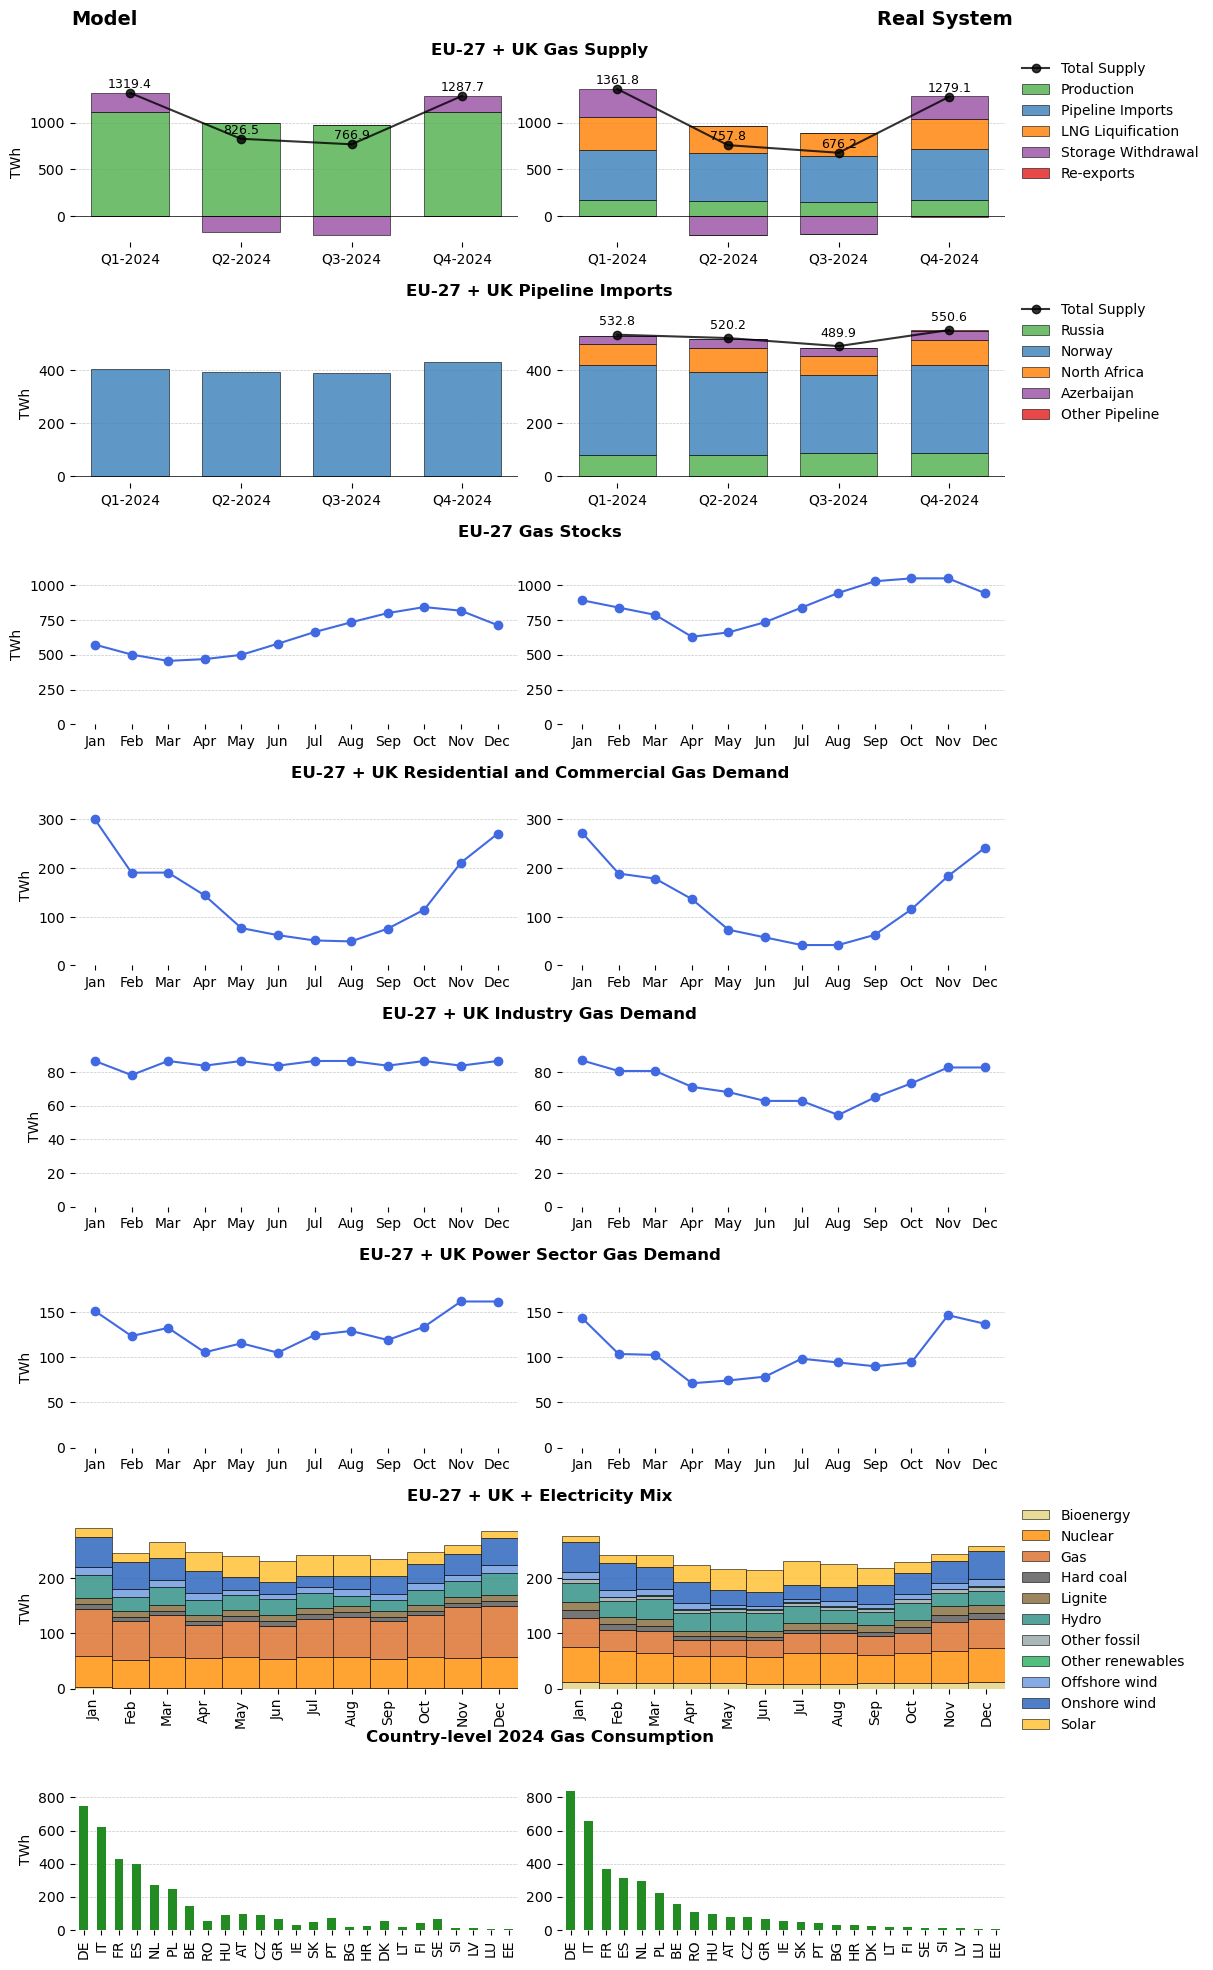

In [153]:
nrows = 8

fig_height = 3 * nrows  # 3 inches per row
fig_width = 12      # 2*2*3 = 12 inches for 2:1 aspect per ax, 2 axes per row
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=2,
    figsize=(fig_width, fig_height),
    gridspec_kw={'wspace':0.1, 'hspace':0.5}
    )

row_fns = [
    plot_total_gas_supply,
    plot_pipeline_imports,
    plot_eu_gas_stock,
    plot_residential_commercial_demand,
    plot_industry_demand,
    plot_power_demand,
    plot_electricity_mix,
    plot_country_consumption,
]

right_data_list = [
    df_total_supply,
    df_pipeline_imports,
    df_storage_2024,
    df_2024_residential,
    df_2024_industrial,
    df_2024_power,
    None,
    ccon,
]

for i in range(nrows):
    model_ax = axes[i, 0]
    true_ax = axes[i, 1]
    row_fns[i](model_ax, true_ax, n, right_data_list[i], fig, i)

    model_ax.set_xlabel("")
    model_ax.set_ylabel("")
    true_ax.set_xlabel("")
    true_ax.set_ylabel("")

    fig.canvas.draw()  # Needed to ensure positions are up to date
    bbox1 = model_ax.get_position()
    bbox2 = true_ax.get_position()

    x0 = bbox1.x1 - 0.02 * (bbox2.x0 - bbox1.x1)  # slight overlap
    width = bbox2.x0 - bbox1.x1 + 0.04 * (bbox2.x0 - bbox1.x1)
    y0 = bbox1.y0
    height = bbox1.height

    bbox_top = model_ax.get_position()
    bbox_bottom = model_ax.get_position()
    y0 = bbox_bottom.y0
    height = (bbox_top.y1 - bbox_bottom.y0) / 5

    '''
    rect = patches.FancyBboxPatch(
        (x0, y0), width, height,
        boxstyle="round,pad=0.02",
        linewidth=1, edgecolor='gray', facecolor='white', alpha=0.95,
        transform=fig.transFigure, zorder=10
    )

    fig.patches.append(rect)

    fig.text(
        x0 + width/2, y0 + height/2,
        f"Legend/Explanation\nPlaceholder\n(Row {i+1})",
        ha='center', va='center', fontsize=10, color='black', zorder=11
    )
    '''

fig.text(0.15, 0.91, 'Model', ha='center', va='top', fontsize=14, fontweight='bold')
fig.text(0.85, 0.91, 'Real System', ha='center', va='top', fontsize=14, fontweight='bold')

for ax in axes[:,0]:
    ax.set_ylabel('TWh')

# plt.savefig('validation_starting_point.pdf', bbox_inches='tight')
plt.show()

In [154]:
chps = pd.read_csv(
    Path.cwd().parent / 'data' / 'combined_chp.csv', index_col=0
)

In [158]:
chps.columns

Index(['name', 'bus', 'carrier', 'p_nom', 'efficiency', 'heat_efficiency',
       'lon', 'lat', 'year_commissioned', 'year_decommissioned', 'type',
       'status', 'source'],
      dtype='object')

In [162]:
chps.loc[chps.carrier == 'Gas']

,name,bus,carrier,p_nom,efficiency,heat_efficiency,lon,lat,year_commissioned,year_decommissioned,type,status,source
id,,,,,,,,,,,,,
Donaustadt1_GAS_CHP,Donaustadt power station,Austria,Gas,395,0.35,0.47,16.463300,48.20000,2001,NaN,chp,operating,NaN
GrazST1_GAS_CHP,Graz power station,Austria,Gas,280,0.35,0.47,15.436700,47.04841,not found,NaN,chp,operating,NaN
Korneuberg1_GAS_CHP,Korneuberg power station,Austria,Gas,158,0.45,0.35,16.340000,48.33250,1983,NaN,chp,operating,NaN
Leopoldau1_GAS_CHP,Leopoldau power station,Austria,Gas,140,0.45,0.35,16.433900,48.27670,1975,NaN,chp,operating,NaN
Linz1 & 2_GAS_CHP,Linz Sd power station,Austria,Gas,172,0.55,0.35,14.346900,48.26789,2000,NaN,chp,operating,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Lulea1_GAS_CHP,Lulea power station,Sweden,Gas,100,0.55,0.35,22.082000,65.57160,2010,NaN,chp,operating,NaN
Rya1_GAS_CHP,Rya Gteborg power station,Sweden,Gas,250,0.55,0.35,11.890500,57.69240,2006,NaN,chp,operating,NaN
Stjarnvik1_GAS_CHP,Stjarnvik power station,Sweden,Gas,60,0.35,0.47,17.054500,58.67350,1998,NaN,chp,operating,NaN


In [167]:
chps.status.value_counts()

status
operating           653
construction         10
pre-construction      7
Name: count, dtype: int64

In [99]:
ss = n.statistics.energy_balance(groupby=['carrier', 'bus'])

ss.loc[
    (ss.index.get_level_values(2).str.contains('gas')) &
    (ss.index.get_level_values(2).str.contains('NO')) &
    (ss.index.get_level_values(1) == 'gas pipeline')
]

component  carrier       bus      
Link       gas pipeline  NO1 0 gas   -1467.44199
dtype: float64

In [153]:
pipes = n.links.index[n.links.carrier == 'gas pipeline']

In [154]:
def get_link_data(c):
    l = n.links.index[n.links.carrier == c]

    cols = ['marginal_cost', 'efficiency', 'capital_cost', 'p_nom', 'p_nom_opt']
    print(n.links.loc[[l[0]], cols])

In [155]:
get_link_data('OCGT')

                 marginal_cost  efficiency  capital_cost  p_nom  p_nom_opt
Link                                                                      
AL0 0 OCGT-2025       1.937615       0.405  19739.577493    0.0   0.035992


In [156]:
get_link_data('CCGT')

                 marginal_cost  efficiency  capital_cost  p_nom  p_nom_opt
Link                                                                      
AL0 0 CCGT-2025       2.604229        0.57   61475.63654    0.0   0.046994


In [157]:
get_link_data('coal')

                 marginal_cost  efficiency   capital_cost        p_nom  \
Link                                                                     
DE0 2 coal-1950       1.170795       0.356  120046.057771  2134.831461   

                   p_nom_opt  
Link                          
DE0 2 coal-1950  2134.831461  


In [158]:
ss = n.links.loc[n.links.carrier.isin(['OCGT', 'CCGT', 'coal', 'lignite'])]
ss.groupby('carrier')[['p_nom', 'p_nom_opt']].sum() / 1e3

,p_nom,p_nom_opt
carrier,,
CCGT,320.815959,353.666057
OCGT,0.057556,37.910214
coal,137.859267,137.859267
lignite,157.953647,157.953647


In [159]:
n.generators.loc[n.generators.carrier.isin(['gas', 'coal', 'lignite']), ['marginal_cost', 'capital_cost', 'carrier']].groupby('carrier').mean()

,marginal_cost,capital_cost
carrier,,
coal,9.564631,0.0
gas,24.578013,0.0
lignite,3.307785,0.0


In [160]:
prices = pd.read_csv(
    Path.cwd().parent / 'data' / 'TERMINAL - PA historical - 2025-10-21.csv', index_col=0, parse_dates=True
)

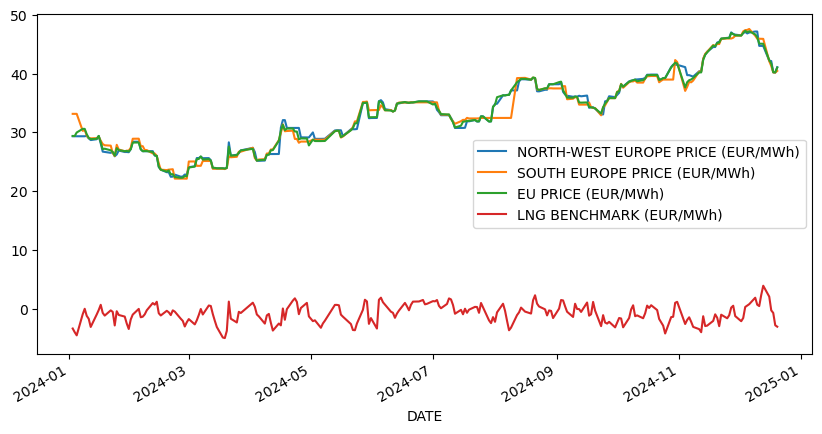

In [161]:
fig, ax = plt.subplots(figsize=(10, 5))
prices.index = pd.to_datetime(prices.index)
prices.loc['2024'].plot(ax=ax)
plt.show()

In [162]:
wbprices = pd.read_excel(
    Path.cwd().parent / 'data' / 'CMO-Historical-Data-Monthly.xlsx', sheet_name='Monthly Prices', header=[4,5,6], index_col=0, parse_dates=True,
)
wbprices = wbprices.loc[wbprices.index.str.contains('2024')]

gas_keepers = ['Natural gas, Europe', 'Liquefied natural gas, Japan']
coal_keepers = ['Coal, Australian', 'Coal, South African **']

wbprices = wbprices.loc[:, gas_keepers + coal_keepers]
wbprices.index = list(map(lambda x: f'{x[:4]}-{x[-2:]}', wbprices.index))

wbprices.columns = wbprices.columns.get_level_values(0)

wbprices.loc[:, gas_keepers] *= 3.152 # conversion from $/MMBtu to EUR/MWh

wbprices.loc[:, 'Lignite'] = 0.1325 * 6000 / 2800 * wbprices.loc[:, 'Coal, Australian']
 # conversion from $/tonne to EUR/MWh (given caloric value read from Description sheet, 6000kcal/kg)
wbprices.loc[:, 'Coal, Australian'] *= 0.1325 # conversion from $/tonne to EUR/MWh (given caloric value read from Description sheet, 6000kcal/kg)
wbprices.loc[:, 'Coal, South African **'] *= 0.1325 # conversion from $/tonne to EUR/MWh (given caloric value read from Description sheet, 6000kcal/kg)

wbprices.rename(
    columns={
        'Natural gas, Europe': 'Europe gas',
        'Liquefied natural gas, Japan': 'Japan LNG',
        'Coal, Australian': 'Australia coal',
        'Coal, South African **': 'South Africa coal',
    },
    inplace=True,
)
wbprices.index = pd.to_datetime(wbprices.index)

/tmp/ipykernel_204804/3515084156.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  wbprices = pd.read_excel(


In [29]:
em = pd.read_csv(
    Path.cwd().parent / 'data' / 'europe_monthly_full_release_long_format.csv', index_col=[1,2]
)

em = em.loc[
    (em['Unit'] == 'TWh') &
    (em['Subcategory'] == 'Fuel')
    ]

In [30]:
em = em.set_index('Variable', append=True)
em = em.loc[em.Area.isin(['EU', 'United Kingdom'])]

em = em.groupby([em.index.get_level_values(2), em.index.get_level_values(1).str[:7]])['Value'].sum().unstack()
em = em.loc[:, em.columns.str.contains('2024')]

In [31]:
em.sum().sum()

2825.89

In [32]:
n.loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'solid biomass for industry',
       'gas for industry', 'H2 for industry', 'industry methanol',
       'naphtha for industry', 'low-temperature heat for industry',
       'industry electricity', 'process emissions', 'NH3',
       'coal for industry', 'shipping oil', 'kerosene for aviation',
       'agriculture electricity', 'agriculture heat',
       'agriculture machinery electric', 'agriculture machinery oil',
       'rural heat', 'urban decentral heat'], dtype=object)

In [33]:
w = n.snapshot_weightings.generators.iloc[0]

In [168]:
el = n.loads.index[(n.loads.carrier == 'electricity') & (~n.loads.index.str.contains(' NO'))]
total_elec_load = (
    n.loads.loc[
        n.loads.carrier.isin(['agriculture electricity', 'industry electricity']) &
        (~n.loads.index.str.contains(' NO')),
        'p_set'].sum() * len(n.snapshots) +
    n.loads_t.p_set.loc[:, el].sum().sum()
) * w * 1e-6
withdrawers = n.links.loc[list(map(lambda x: 'low voltage' in x, n.links.bus0))].index
withdrawers = withdrawers[~withdrawers.str.contains('NO ')]
heating_transport_demand = n.links_t.p0.loc[:, withdrawers].sum().sum() * w * 1e-6

total_elec_load += heating_transport_demand
total_elec_load

3140.5574803785225

In [171]:
em.sum().sum()

2825.89

In [174]:
n.links_t.p0.loc[:, n.links.carrier == 'BEV charger'].sum().sum() * w * 1e-6

54.01183943036321

In [ ]:
n.links_t.p_set.T[
    () *
]

In [36]:
demands = ['urban central heat', 'urban decentral heat', 'rural heat']

heat_buses = n.buses.index[n.buses.carrier.isin(demands)]

heat_generators = n.generators.index[n.generators.bus.isin(heat_buses)]
heat_generator_carriers = n.generators.loc[heat_generators, 'carrier'].unique()

heat_links = n.links.index[n.links.bus0.isin(heat_buses) | n.links.bus1.isin(heat_buses) | n.links.bus2.isin(heat_buses) | n.links.bus3.isin(heat_buses)]
heat_link_carriers = n.links.loc[heat_links, 'carrier'].unique()

heat_loads = n.loads.index[n.loads.bus.isin(heat_buses)]
heat_load_carriers = n.loads.loc[heat_loads, 'carrier'].unique()

all_heat_carriers = pd.Index(heat_generator_carriers).union(pd.Index(heat_link_carriers))

In [104]:
import yaml

with open(Path.cwd().parent / 'config.basicrun.yaml', 'r') as f:
    tech_colors = yaml.safe_load(f)['plotting']['tech_colors']

In [105]:
idx = pd.IndexSlice

eb = n.statistics.energy_balance(groupby=['carrier', 'bus'])
eb = eb.loc[idx[:, :, heat_buses]]
eb = eb.groupby([eb.index.get_level_values(1), eb.index.get_level_values(2).str[:2]]).sum()
eb = eb.loc[eb > 0].unstack().replace(np.nan, 0)
eb = eb.loc[eb.sum(axis=1).sort_values(ascending=False).index, eb.sum().sort_values(ascending=False).index].mul(1e-6)

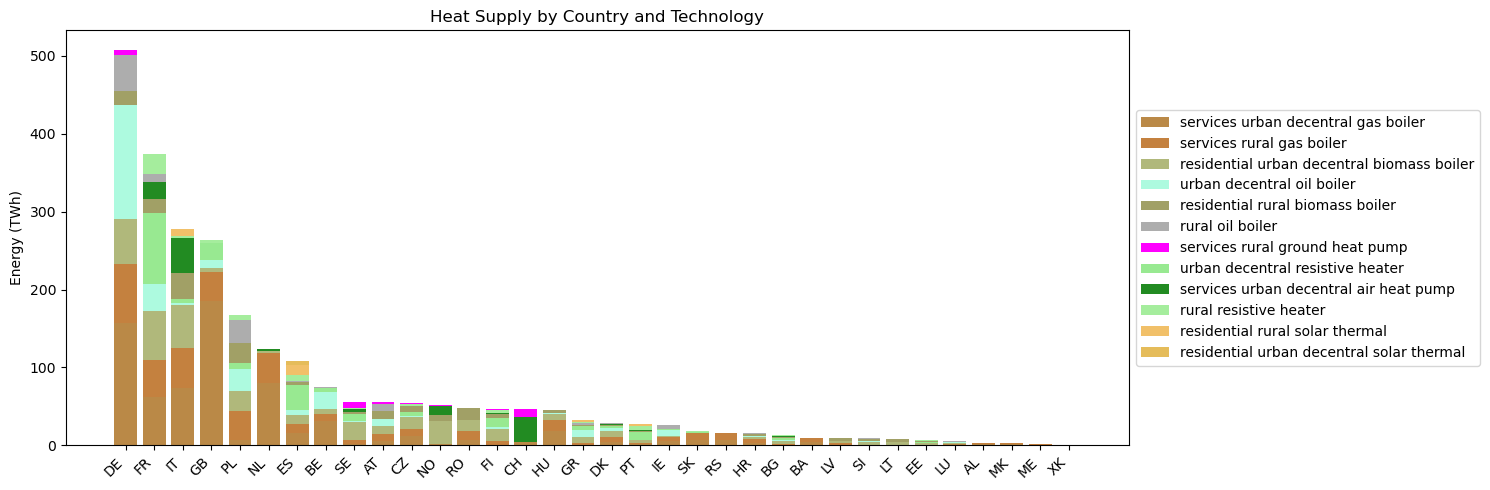

In [106]:
fig, ax = plt.subplots(figsize=(15, 5))

for i, c in enumerate(eb.columns):
    col_data = eb[c]
    col_total = col_data.sum()
    
    # Filter for carriers contributing more than 1%
    significant = col_data[col_data > 0.01 * col_total]
    
    # Get colors for each carrier
    colors = [tech_colors.get(carrier, '#808080') for carrier in significant.index]
    
    # Create stacked bar
    bottom = 0
    for carrier, value in significant.items():
        color = tech_colors.get(carrier, '#808080')
        ax.bar(i, value, bottom=bottom, color=color, label=carrier, width=0.8)
        bottom += value

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1, 0.5))

ax.set_xticks(range(len(eb.columns)))
ax.set_xticklabels(eb.columns, rotation=45, ha='right')
ax.set_ylabel('Energy (TWh)')
ax.set_title('Heat Supply by Country and Technology')

plt.tight_layout()

plt.show()

In [107]:
n.loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'solid biomass for industry',
       'gas for industry', 'H2 for industry', 'industry methanol',
       'naphtha for industry', 'low-temperature heat for industry',
       'industry electricity', 'process emissions', 'NH3',
       'coal for industry', 'shipping oil', 'kerosene for aviation',
       'agriculture electricity', 'agriculture heat',
       'agriculture machinery electric', 'agriculture machinery oil',
       'rural heat', 'urban decentral heat'], dtype=object)

In [108]:
ss = n.links.loc[n.links.carrier.isin(eb.index)]
ss = ss.groupby(['carrier', 'bus1'])['p_nom_opt'].sum().unstack()
ss = ss.T.groupby(ss.columns.str[:2]).sum().T.mul(1e-3)
ss.columns = ss.columns.str[:2]
ss = ss.loc[ss.sum(axis=1) > 0]
ss = ss.loc[:, ss.sum().sort_values(ascending=False).index]

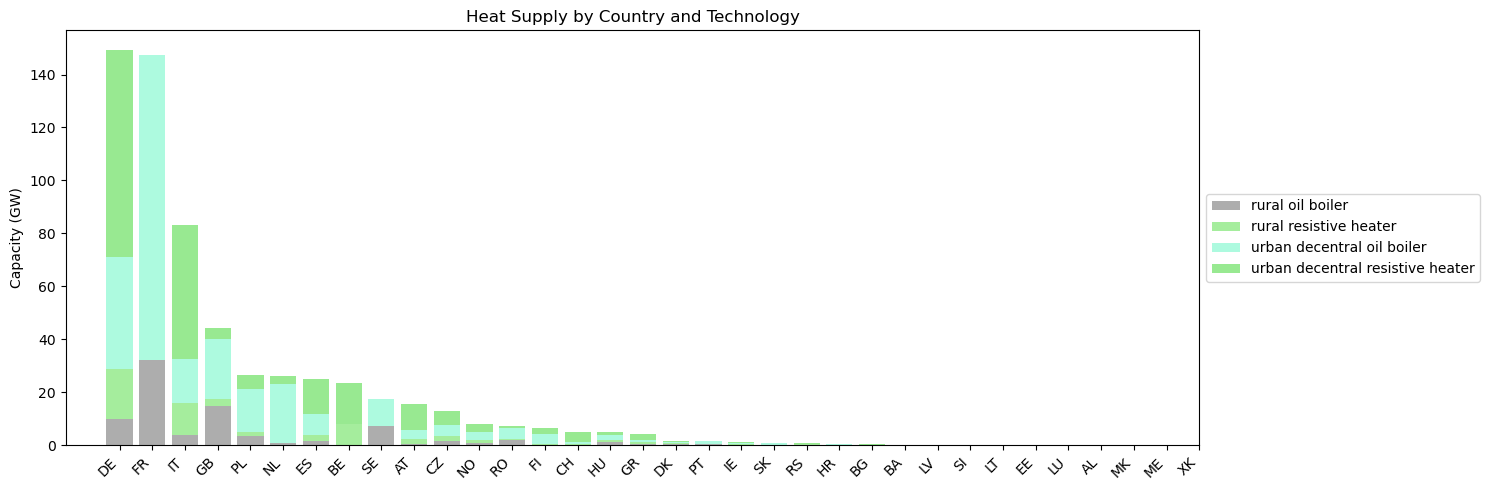

In [109]:

fig, ax = plt.subplots(figsize=(15, 5))

for i, c in enumerate(ss.columns):
    col_data = ss[c]
    col_total = col_data.sum()
    
    # Filter for carriers contributing more than 1%
    significant = col_data[col_data > 0.01 * col_total]
    
    # Get colors for each carrier
    colors = [tech_colors.get(carrier, '#808080') for carrier in significant.index]
    
    # Create stacked bar
    bottom = 0
    for carrier, value in significant.items():
        color = tech_colors.get(carrier, '#808080')
        ax.bar(i, value, bottom=bottom, color=color, label=carrier, width=0.8)
        bottom += value

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1, 0.5))

ax.set_xticks(range(len(eb.columns)))
ax.set_xticklabels(eb.columns, rotation=45, ha='right')
ax.set_ylabel('Capacity (GW)')
ax.set_title('Heat Supply by Country and Technology')

plt.tight_layout()

plt.show()

In [110]:
cf = n.statistics()['Capacity Factor']

In [111]:
n.links.index[n.links.index.str.contains('residential')]

Index([], dtype='object', name='Link')

In [112]:
'residential urban decentral gas boiler' in n.links.carrier.unique()

False

In [113]:
heat_carriers = [
    'urban decentral heat',
    # 'urban central heat',
    'rural heat',
]

heat_buses = n.buses.index[
    n.buses.carrier.isin(heat_carriers)
    ]

carriers = n.links.loc[n.links.bus1.isin(heat_buses), 'carrier'].unique()

supply = pd.DataFrame(index=n.snapshots, columns=carriers)

for c in carriers:
    supply.loc[:, c] = n.links_t.p1.loc[:, n.links.carrier == c].sum(axis=1).mul(-1e-3)

supply = supply.groupby(lambda x: ' '.join(x.split()[-2:]), axis=1).sum()
supply = supply.div(supply.sum(axis=1), axis=0)

/tmp/ipykernel_408443/880755503.py:18: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  supply = supply.groupby(lambda x: ' '.join(x.split()[-2:]), axis=1).sum()


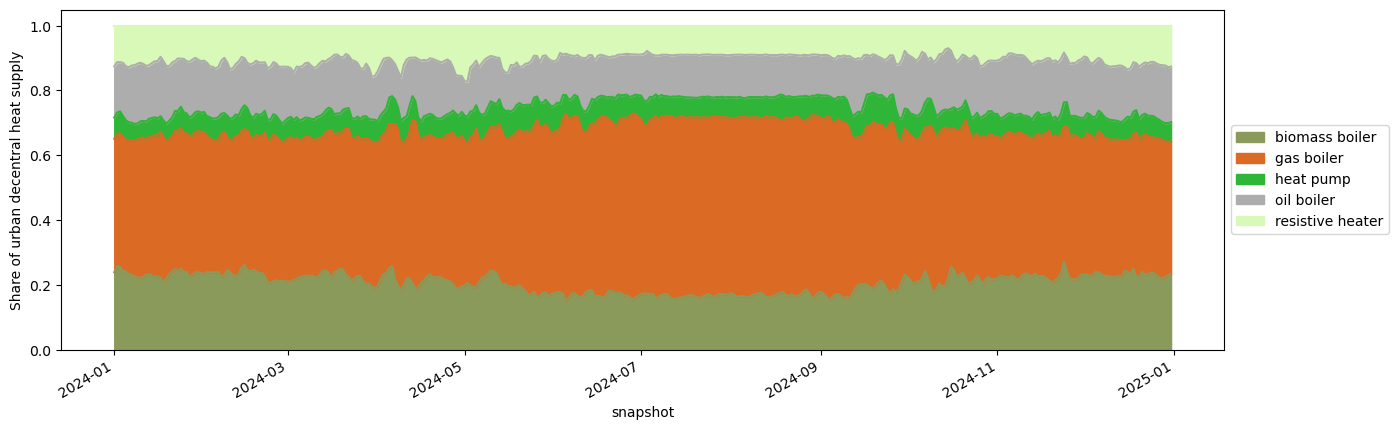

In [114]:
fig, ax = plt.subplots(figsize=(15, 5))
import random
colors = [tech_colors.get(carrier, f'#{random.randint(0, 0xFFFFFF):06x}') for carrier in supply.columns]

supply.plot.area(ax=ax, color=colors, legend=False)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylabel('Share of urban decentral heat supply')
plt.show()

In [56]:
remove_countries

['NO', 'AL', 'BA', 'ME', 'MK', 'NO', 'RS', 'XK']

In [61]:
eb = n.statistics.energy_balance(groupby=['carrier', 'bus', 'bus_carrier'])
eb = eb.loc[idx[:, :, :, 'AC']]
eb = eb.loc[~eb.index.get_level_values(2).str[:2].isin(remove_countries)]
eb = eb.loc[eb < 0]
eb.sum() * 1e-6

-3665.5033794661495

In [115]:
em = pd.read_csv(
    Path.cwd().parent / 'data' / 'europe_monthly_full_release_long_format.csv', index_col=[1,2]
)

em = em.loc[
    (em['Unit'] == 'TWh') &
    (em['Subcategory'] == 'Fuel')
    ]
em = em.set_index('Variable', append=True)
em = em.loc[em.Area.isin(['EU', 'United Kingdom'])]

em = em.groupby([em.index.get_level_values(2), em.index.get_level_values(1).str[:7]])['Value'].sum().unstack()
em = em.loc[:, em.columns.str.contains('2024')].T

keepers = [
    'Pumped Hydro Storage',
    'Reservoir & Dam',
    'Offshore Wind (AC)',
    'Offshore Wind (DC)',
    'Offshore Wind (Floating)',
    'Onshore Wind',
    'Run of River',
    'Solar',
    'nuclear',
    'lignite',
    'solar-hsat',
    'Combined-Cycle Gas',
    'Open-Cycle Gas',
    'coal',
    'urban central gas CHP CC',
    'urban central solid biomass CHP',
    'urban central solid biomass CHP CC',
]
grouper = {
    "Offshore Wind (AC)": "Offshore wind",
    "Offshore Wind (DC)": "Offshore wind",
    "Offshore Wind (Floating)": "Offshore wind",
    "Onshore Wind": "Onshore wind",
    "Run of River": "Hydro",
    "Pumped Hydro Storage": "Hydro",
    "Reservoir & Dam": "Hydro",
    "urban central gas CHP CC": "Gas",
    "urban central solid biomass CHP CC": "Bioenergy",
    "urban central solid biomass CHP": "Bioenergy",
    "Open-Cycle Gas": "Gas",
    "Combined-Cycle Gas": "Gas",
    "coal": "Hard coal",
    "lignite": "Lignite",
    "nuclear": "Nuclear",
    "solar": "Solar",
    "solar-hsat": "Solar",
}
grouper = {
    origin: grouper.get(origin, origin) for origin in keepers
}

weight = n.snapshot_weightings['generators'].iloc[0]
idx = pd.IndexSlice

# ns = n.statistics.energy_balance(aggregate_time=False).loc[idx[:,:,'AC']]
# ns.index = ns.index.get_level_values(1)

energy_colors = {
    'Bioenergy': '#e3d37d',
    'Nuclear': '#ff8c00',
    'Gas': '#db6a25',
    'Hard coal': '#545454',
    'Lignite': '#826837',
    'Hydro': '#298c81',
    'Other fossil': '#95A5A6',
    'Other renewables': '#27AE60',
    'Offshore wind': "#6895dd",
    'Onshore wind': "#235ebc",
    'Solar': '#ffbf2b',
}

em.loc[:, pd.Index(energy_colors.keys()).difference(em.columns)] = 0

In [121]:
avg_coal_operation = em['Hard coal'].sum() / 8760 * 1e3
avg_lignite_operation = em['Lignite'].sum() / 8760 * 1e3

104.55000000000001

In [122]:
avg_coal_operation

11.934931506849317

In [124]:
avg_lignite_operation

17.547945205479447

In [135]:
lgn = n.links.loc[n.links.carrier == 'lignite']
lgn.groupby(lgn.index.str[:2])['p_nom'].sum().sort_values() * 0.33 / 1e3

Link
ME     0.207481
IE     0.253000
SK     0.285863
MK     0.737712
HU     0.815172
FR     0.977000
SI     1.005422
XK     1.187716
BA     1.911596
BG     2.145137
CZ     2.741522
RO     2.803305
GR     3.331761
RS     4.740504
PL     7.522602
DE    21.458910
Name: p_nom, dtype: float64

In [136]:
n.links.loc[n.links.carrier == 'lignite', 'p_nom'].sum() / 1e3 / 3

52.651215782019754

In [140]:
hc = n.links.loc[n.links.carrier == 'coal']
print(hc.groupby(hc.index.str[:2])['p_nom'].sum().sum() * 0.35 / 1e3)
hc.groupby(hc.index.str[:2])['p_nom'].sum().sort_values() * 0.35 / 1e3

48.25074330621147


Link
BG     0.157713
RO     0.190344
HU     0.226600
DK     0.372530
SK     0.378191
CZ     0.771736
IE     0.829355
FR     1.142062
FI     1.427142
ES     2.190468
NL     6.193714
IT     7.153298
PL    13.246403
DE    13.971188
Name: p_nom, dtype: float64

In [62]:
df_total_supply

,Production,Pipeline_Import,LNG_Sendout,Net_Storage_Withdrawal,Re_exports,Total_Supply
Quarter,,,,,,
Q2-2023,173.7522,456.3612,418.6800,-238.6476,-4.1868,804.9123
Q3-2023,163.2852,463.6881,312.9633,-213.5268,-29.3076,699.1956
Q4-2023,171.6588,543.2373,387.2790,102.5766,-10.4670,1198.4715
Q1-2024,169.5654,532.7703,355.8780,306.6831,-3.1401,1361.7567
Q2-2024,153.8649,520.2099,294.1227,-203.0598,-3.1401,757.8108
Q3-2024,150.7248,489.8556,242.8344,-197.8263,-3.1401,676.1682
Q4-2024,166.4253,550.5642,324.4770,248.0679,-9.4203,1279.0674
Q1-2025,164.3319,490.9023,409.2597,432.2871,-6.2802,1485.2673
Q2-2025,164.3319,455.3145,392.5125,-276.3288,-15.7005,720.1296


In [188]:
w = n.snapshot_weightings.generators.iloc[0]
n.loads.loc[n.loads.carrier == 'gas for industry', 'p_set'].sum() * w * len(n.snapshots) * 1e-6

1175.3200000000002

In [10]:
ss = n.statistics.withdrawal(groupby=['carrier', 'bus'], aggregate_time=False)
mask = n.buses.loc[ss.index.get_level_values(2).intersection(n.buses.index)].carrier == 'gas'
mask.loc[''] = False
mask = [mask[entry] for entry in ss.index.get_level_values(2)]

ss = ss.loc[mask].dropna()
ss = ss.loc[~ss.index.get_level_values(2).str[2].isin(['CH', 'NO', 'AL', 'BG', 'ME', 'MK', 'RS', 'XK'])]

# industry_consumption = ss.groupby(level=1).sum().T[industry_demands].sum(axis=1).mul(n.snapshot_weightings['generators'])
industry_consumption = ss.groupby(level=1).sum().T[['gas for industry']].sum(axis=1).mul(n.snapshot_weightings['generators'])
print(industry_consumption.sum() * 1e-6)

1175.3148914136


In [11]:
n.loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'solid biomass for industry',
       'gas for industry', 'H2 for industry', 'industry methanol',
       'naphtha for industry', 'low-temperature heat for industry',
       'industry electricity', 'process emissions', 'NH3',
       'coal for industry', 'shipping oil', 'kerosene for aviation',
       'agriculture electricity', 'agriculture heat',
       'agriculture machinery electric', 'agriculture machinery oil',
       'rural heat', 'urban decentral heat'], dtype=object)

In [15]:
df_2024_industrial.sum()

870.8544

In [ ]:
wiggle = 0.0001

for bus in heat_buses:

    if not bus.startswith('DE'):
        continue

    busload = n.loads_t.p_set.loc[:, n.loads.index[n.loads.index.str.contains(bus)]]

    inc_links = n.links.index[n.links.bus1 == bus]

    supply_capacities = pd.Series(0, index=inc_links)
    efficiencies = pd.Series(0, index=inc_links)

    profiles = {}

    for link in inc_links:
        if link in n.links_t.efficiency.columns:
            link_eff = n.links_t.efficiency.loc[:, link].mean()
            efficiencies.loc[link] = link_eff
        else:
            link_eff = n.links.loc[link, 'efficiency']
            efficiencies.loc[link] = link_eff

        link_cap = n.links.loc[link, 'p_nom']
        supply_capacities.loc[link] = link_cap * link_eff

    if supply_capacities.sum() == 0:
        continue

    shares = supply_capacities.div(supply_capacities.sum())
    operation_profile = busload / busload.max() * (supply_capacities.sum() / busload.max())

    for link, share in shares.items():

        if 'gas boiler' in n.links.loc[link, 'carrier']:
            continue

        p_pu = share * operation_profile 
        p_pu.columns = [link]

        profiles[link] = p_pu


    print(pd.concat(profiles.values(), axis=1))
    break


DE0 0 rural heat
Load        DE0 0 rural heat
snapshot                    
2024-01-01       4012.972570
2024-01-02       4189.833945
2024-01-03       3271.798448
2024-01-04       5585.358570
2024-01-05       5973.393623
...                      ...
2024-12-27       5566.012737
2024-12-28       6664.584448
2024-12-29       6142.877650
2024-12-30       4838.592842
2024-12-31       5242.041021

[365 rows x 1 columns]
Link
DE0 0 rural air heat pump-2025       0.00
DE0 0 rural biomass boiler-2025      0.00
DE0 0 rural gas boiler-2010          0.17
DE0 0 rural gas boiler-2015          0.17
DE0 0 rural gas boiler-2019          0.14
DE0 0 rural gas boiler-2025          0.00
DE0 0 rural ground heat pump-2010    0.02
DE0 0 rural ground heat pump-2015    0.02
DE0 0 rural ground heat pump-2019    0.01
DE0 0 rural ground heat pump-2025    0.00
DE0 0 rural oil boiler-2010          0.16
DE0 0 rural oil boiler-2015          0.16
DE0 0 rural oil boiler-2019          0.13
dtype: float64
            DE0 

/tmp/ipykernel_204804/1367571308.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.744991858362324' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  efficiencies.loc[link] = link_eff
/tmp/ipykernel_204804/1367571308.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1574.351978634866' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  supply_capacities.loc[link] = link_cap * link_eff


In [66]:
n.links.carrier.unique()

array(['DC', 'oil refining', 'co2 sequestered', 'OCGT', 'CCGT',
       'H2 Electrolysis', 'gas pipeline', 'gas pipeline new',
       'battery charger', 'battery discharger', 'Sabatier', 'SMR CC',
       'SMR', 'BEV charger', 'V2G', 'land transport oil',
       'urban central air heat pump', 'urban central gas boiler',
       'urban central gas CHP', 'urban central gas CHP CC',
       'unsustainable bioliquids', 'biogas to gas',
       'urban central solid biomass CHP',
       'urban central solid biomass CHP CC', 'biomass to liquid',
       'electrobiofuels', 'Haber-Bosch', 'ammonia cracker',
       'biomass-to-methanol', 'OCGT methanol',
       'solid biomass for industry', 'solid biomass for industry CC',
       'gas for industry', 'gas for industry CC', 'industry methanol',
       'methanolisation', 'Fischer-Tropsch', 'naphtha for industry',
       'HVC to air', 'process emissions', 'process emissions CC',
       'coal for industry', 'shipping oil', 'kerosene for aviation',
       '

In [88]:
net.links.carrier.unique()

array(['DC', 'oil refining', 'co2 sequestered', 'OCGT', 'CCGT',
       'H2 Electrolysis', 'gas pipeline', 'gas pipeline new',
       'battery charger', 'battery discharger', 'Sabatier', 'SMR CC',
       'SMR', 'BEV charger', 'V2G', 'land transport oil',
       'residential rural air heat pump',
       'residential rural ground heat pump',
       'residential rural gas boiler', 'services rural air heat pump',
       'services rural ground heat pump', 'services rural gas boiler',
       'residential urban decentral air heat pump',
       'residential urban decentral gas boiler',
       'services urban decentral air heat pump',
       'services urban decentral gas boiler',
       'urban central air heat pump', 'urban central gas boiler',
       'urban central gas CHP', 'urban central gas CHP CC',
       'unsustainable bioliquids', 'biogas to gas',
       'urban central solid biomass CHP',
       'urban central solid biomass CHP CC',
       'residential rural biomass boiler',
       'servi

In [ ]:
caps = n.statistics.optimal_capacity(groupby=['carrier', 'bus']).loc[idx['Link']]
relevant_tech = caps.index.get_level_values(0).unique().intersection(all_heat_carriers)
caps = caps.loc[idx[relevant_tech]]
caps = caps.groupby([caps.index.get_level_values(0), caps.index.get_level_values(1).str[:2]]).sum()
caps = caps.loc[caps > 0].unstack().replace(np.nan, 0)
caps = caps.loc[caps.sum(axis=1).sort_values(ascending=False).index, caps.sum().sort_values(ascending=False).index].mul(1e-3)

In [ ]:
n.links.loc[n.links.carrier == 'urban decentral air heat pump']

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,reversed,project_status,geometry,dc,under_construction,voltage,length_original,underground,tags,underwater_fraction
Link,,,,,,,,,,,,,,,,,,,,,
AL0 0 urban decentral air heat pump-2025,AL0 0 low voltage,AL0 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2025,18.0,0.000000,0.0,...,False,,,NaN,NaN,NaN,0.0,NaN,,NaN
AT0 0 urban decentral air heat pump-2010,AT0 0 low voltage,AT0 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2010,18.0,73.469388,0.0,...,False,,,NaN,NaN,NaN,NaN,NaN,,NaN
AT0 0 urban decentral air heat pump-2015,AT0 0 low voltage,AT0 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2015,18.0,73.469388,0.0,...,False,,,NaN,NaN,NaN,NaN,NaN,,NaN
AT0 0 urban decentral air heat pump-2019,AT0 0 low voltage,AT0 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2019,18.0,58.775510,0.0,...,False,,,NaN,NaN,NaN,NaN,NaN,,NaN
AT0 0 urban decentral air heat pump-2025,AT0 0 low voltage,AT0 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2025,18.0,0.000000,0.0,...,False,,,NaN,NaN,NaN,0.0,NaN,,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SE1 0 urban decentral air heat pump-2019,SE1 0 low voltage,SE1 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2019,18.0,279.183673,0.0,...,False,,,NaN,NaN,NaN,NaN,NaN,,NaN
SE1 0 urban decentral air heat pump-2025,SE1 0 low voltage,SE1 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2025,18.0,0.000000,0.0,...,False,,,NaN,NaN,NaN,0.0,NaN,,NaN
SI0 0 urban decentral air heat pump-2025,SI0 0 low voltage,SI0 0 urban decentral heat,,urban decentral air heat pump,1.0,True,2025,18.0,0.000000,0.0,...,False,,,NaN,NaN,NaN,0.0,NaN,,NaN


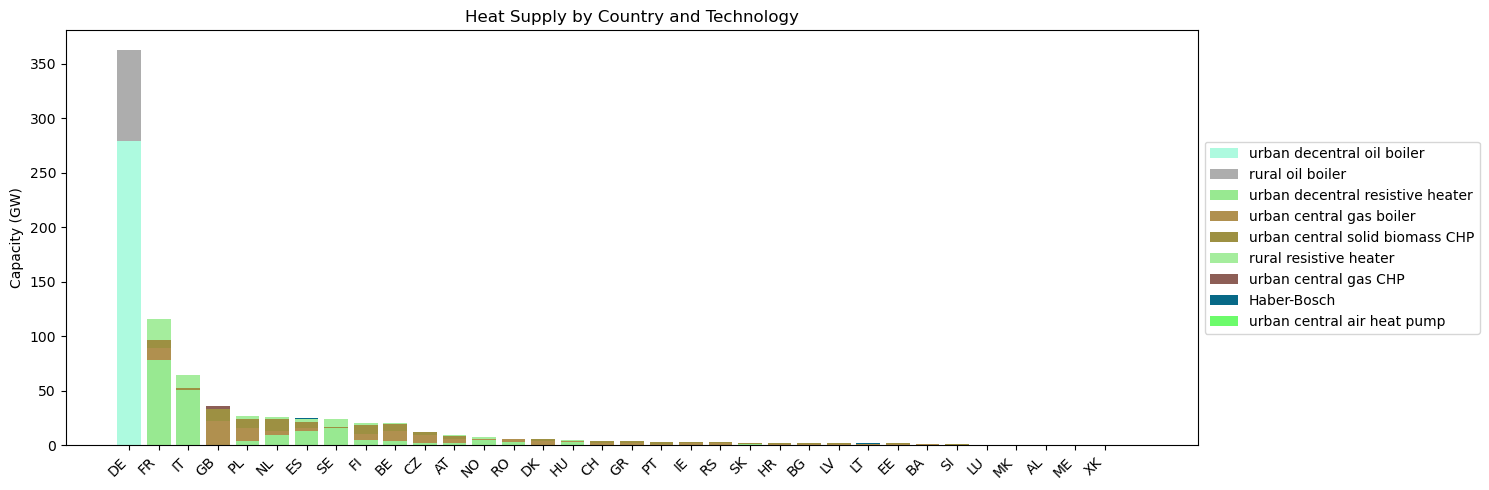

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))

for i, c in enumerate(caps.columns):
    col_data = caps[c]
    col_total = col_data.sum()
    
    # Filter for carriers contributing more than 1%
    significant = col_data[col_data > 0.01 * col_total]
    
    # Get colors for each carrier
    colors = [tech_colors.get(carrier, '#808080') for carrier in significant.index]
    
    # Create stacked bar
    bottom = 0
    for carrier, value in significant.items():
        color = tech_colors.get(carrier, '#808080')
        ax.bar(i, value, bottom=bottom, color=color, label=carrier, width=0.8)
        bottom += value

# Add legend on the right
handles, labels = ax.get_legend_handles_labels()
# Remove duplicates while preserving order
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1, 0.5))

# Set x-axis labels
ax.set_xticks(range(len(eb.columns)))
ax.set_xticklabels(eb.columns, rotation=45, ha='right')
ax.set_ylabel('Capacity (GW)')
ax.set_title('Heat Supply by Country and Technology')

plt.tight_layout()

plt.show()

In [7]:
final_carriers = ['Wind Onshore', 'Wind Offshore', 'Coal', 'Lignite', 'Gas', 'Hydro', 'Nuclear', 'Solar', 'Biomass', 'Waste', 'Geothermal']

In [8]:
eu_mapping = {
    'Biomass': 'Biomass',
    'Waste': 'Waste',
    'Fossil Brown coal/Lignite': 'Lignite',
    'Fossil Hard coal': 'Coal',
    'Fossil Coal-derived gas': 'Gas',
    'Fossil Gas': 'Gas',
    'Fossil Oil': 'Gas',
    'Fossil Oil shale': 'Gas',
    'Fossil Peat': 'Gas',
    'Geothermal': 'Geothermal',
    'Hydro Pumped Storage': 'Hydro',
    'Hydro Run-of-river and poundage': 'Hydro',
    'Hydro Water Reservoir': 'Hydro',
    'Marine': 'Hydro',
    'Nuclear': 'Nuclear',
    'Other': 'Gas',
    'Other renewable': 'Biomass',
    'Solar': 'Solar',
    'Wind Offshore': 'Wind Offshore',
    'Wind Onshore': 'Wind Onshore',
}

uk_mapping = {
    'Coal [note 4]': 'Coal',
    'Oil [note 5]': 'Gas',
    'OCGT and conventional thermal gas [note 5]': 'Gas',
    'CCGT gas': 'Gas',
    'Nuclear - Magnox': 'Nuclear',
    'Nuclear - PWR': 'Nuclear',
    'Nuclear - AGR': 'Nuclear',
    'Hydro (natural flow)': 'Hydro',
    'Wind (onshore)': 'Wind Onshore',
    'Wind (offshore)': 'Wind Offshore',
    'Solar': 'Solar',
    'Wave and tidal': 'Hydro',
    'Bioenergy': 'Biomass',
    'Other fuels [note 6]': 'Gas',
    'Pumped storage [note 7]': 'Hydro',
}

In [9]:
cap = pd.read_csv(
    Path.cwd().parent / 'data' / 'net_generation_capacity_2024.csv', 
    sep='\t',
    index_col=[3,4]
)['ProvidedValue'].unstack().replace(np.nan, 0).groupby(eu_mapping).sum()

In [10]:
idx = pd.IndexSlice

ukcap = pd.read_excel(
    Path.cwd().parent / 'data' / 'DUKES_5.12.xlsx',
    sheet_name='5.12',
    header=6,
    index_col=[0,1]
)['2024'].loc[idx['All']]

In [11]:
ukcap = ukcap.groupby(uk_mapping).sum()
cap['GB'] = ukcap

cap = cap.replace(np.nan, 0)

In [12]:
cap.index

Index(['Biomass', 'Coal', 'Gas', 'Geothermal', 'Hydro', 'Lignite', 'Nuclear',
       'Solar', 'Waste', 'Wind Offshore', 'Wind Onshore'],
      dtype='object', name='Category')

In [13]:
cap


Country,AL,AT,BA,BE,BG,CH,CZ,DE,DK,EE,...,MK,NL,NO,PL,PT,RO,RS,SE,SI,GB
Category,,,,,,,,,,,,,,,,,,,,,
Biomass,0.0,549.00,0.0,730.82,74.0,0.0,870.0,8932.99,0.0,150.3,...,7.0,415.0,113.88,662.30,681.0,118.0,2.38,0.0,43.39,6696.334546
Coal,0.0,0.00,0.0,0.00,356.0,0.0,1200.0,18411.00,0.0,0.0,...,0.0,4006.0,0.00,18830.51,0.0,176.0,0.00,0.0,0.00,6.776299
Gas,97.0,5229.00,0.0,7473.50,699.0,0.0,1620.0,43260.00,0.0,1443.7,...,416.0,18352.0,504.18,7471.29,4460.7,2238.0,641.35,6600.0,814.04,36945.447879
Geothermal,0.0,0.25,0.0,0.00,0.0,0.0,0.0,54.00,0.0,0.0,...,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.000000
Hydro,2203.0,11821.00,2148.0,1493.51,3213.0,13103.2,2278.0,14560.80,0.0,8.0,...,644.0,38.0,34600.35,2377.30,8191.9,6139.0,3179.29,16300.0,1305.24,4799.453570
Lignite,0.0,0.00,1883.0,0.00,4119.0,0.0,7200.0,18363.00,0.0,0.0,...,824.0,0.0,0.00,7557.00,0.0,1733.0,6010.50,0.0,1190.50,0.000000
Nuclear,0.0,0.00,0.0,3929.00,2080.0,2970.0,4040.0,0.00,0.0,0.0,...,0.0,486.0,0.00,0.00,0.0,1300.0,0.00,6900.0,696.00,5883.000000
Solar,195.0,7294.00,29.9,8788.79,4055.0,0.0,3548.0,76600.56,3730.0,812.0,...,0.0,24261.0,9.07,14608.70,1810.8,1293.0,29.13,3200.0,1109.53,18260.239221
Waste,0.0,80.00,0.0,383.64,6.0,0.0,100.0,1808.00,0.0,17.0,...,0.0,786.0,91.96,0.00,0.0,0.0,32.40,0.0,6.31,0.000000


In [14]:
plot_carriers = [
    ('Biomass', ['urban central solid biomass CHP'], 'links'),
    ('Gas', ['OCGT', 'CCGT'], 'links'),
    ('Coal', ['coal'], 'links'),
    ('Lignite', ['lignite'], 'links'),
    ('Nuclear', ['nuclear'], 'links'),
    ('Hydro', ['ror', 'hydro', 'PHS'], ['generators', 'storage_units', 'storage_units']),
    ('Solar', ['solar', 'solar-hsat', 'solar rooftop'], 'generators'),
    ('Wind Onshore', ['onwind'], 'generators'),
    ('Wind Offshore', ['offwind-ac', 'offwind-dc', 'offwind-float'], 'generators')
]

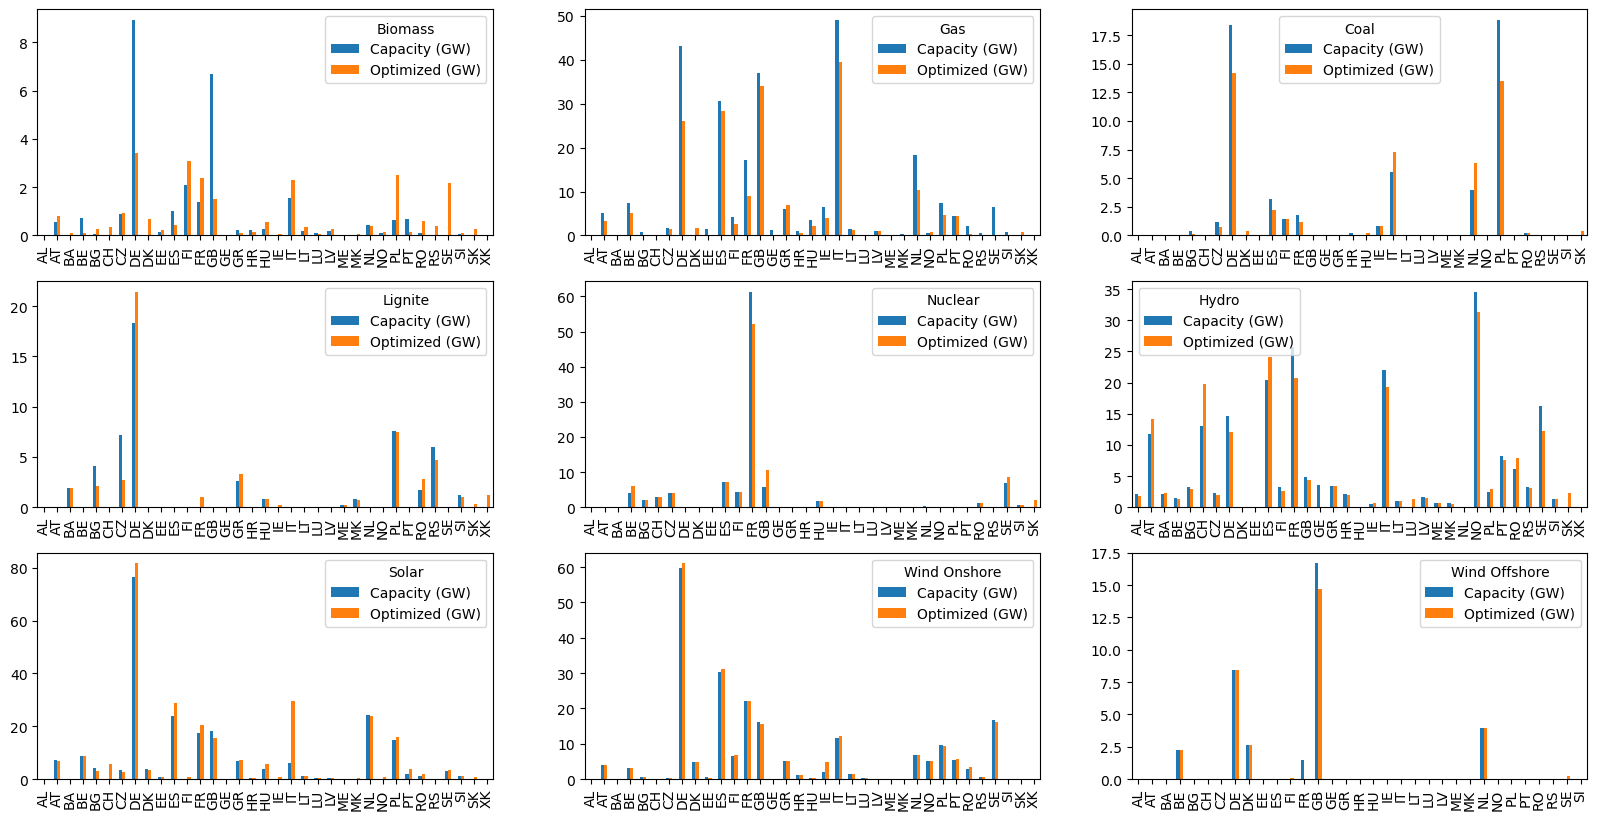

In [15]:
fig, axs = plt.subplots(3, 3, figsize=(20, 10))

for (nc, pypsa_carriers, comp), ax in zip(plot_carriers, axs.flatten()):

    if isinstance(comp, str):
        gen = getattr(n, comp).loc[getattr(n, comp).carrier.isin(pypsa_carriers), 'p_nom_opt']

        if comp == 'links':
            eta = n.links.loc[n.links.carrier.isin(pypsa_carriers), 'efficiency']
            gen = gen.mul(eta)
    else:
        gens = []
        for c, ps in zip(comp, pypsa_carriers):
            this_gen = getattr(n, c).loc[getattr(n, c).carrier == ps, 'p_nom_opt']
            gens.append(this_gen)
        gen = pd.concat(gens)

    gen = gen.groupby(gen.index.str[:2]).sum()

    df = pd.DataFrame({
        'Capacity (GW)': cap.loc[nc],
        'Optimized (GW)': gen
    }).fillna(0).mul(1e-3)

    df.plot.bar(ax=ax)
    ax.legend(title=nc)

plt.show()


In [201]:
n.generators.loc[n.generators.carrier == 'solar rooftop'].iloc[[0]].T

Generator,AL0 0 0 solar rooftop-2025
bus,AL0 0 low voltage
control,PQ
type,
p_nom,0.0
p_nom_mod,0.0
p_nom_extendable,True
p_nom_min,0.0
p_nom_max,5281.542575
p_min_pu,0.0
p_max_pu,1.0


In [176]:
wind = n.generators.loc[n.generators.carrier == 'solar', ['p_nom', 'p_nom_opt', 'p_nom_extendable']]
wind = wind.groupby(wind.index.str[:2]).agg(
    {'p_nom': 'sum', 'p_nom_opt': 'sum', 'p_nom_extendable': 'max'}
)
wind

,p_nom,p_nom_opt,p_nom_extendable
Generator,,,
AL,162.000000,162.000000,False
AT,6832.686000,6832.686000,False
BA,123.720000,123.720000,False
BE,8547.100000,8547.100000,False
BG,2948.184000,2948.184000,False
CH,5839.920000,5839.920000,False
CZ,2505.695000,2505.695000,False
DE,81737.000000,81737.000000,False
DK,3522.000000,3522.000000,False


In [ ]:
n.statistics.energy_balance(groupby

Unnamed PyPSA Network
---------------------
Components:
 - Bus: 1211
 - Carrier: 114
 - Generator: 1419
 - GlobalConstraint: 5
 - Line: 97
 - Link: 4566
 - Load: 952
 - StorageUnit: 68
 - Store: 406
Snapshots: 365